In [25]:
#==========================
#
# Neural Network + JEV Integration Layer
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [26]:
import os
import json
from pathlib import Path
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

MODEL_VERSION = "enterprise-doc-mlp-v2"

JEV_BASE_URL = "https://api.typesafe.ai"
JEV_ENDPOINT = f"{JEV_BASE_URL}/v1/systemone"
JEV_MODEL = os.getenv("JEV_MODEL", "jev-latest")

ARTIFACT_DIR = Path("enterprise_document_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

In [27]:
templates = {
    "INVOICE": [
        "Invoice {id} from {company}. Total amount due is ${amount}.",
        "Please remit payment of ${amount} to {company}. Invoice number {id}.",
        "Billing statement from {company} showing an outstanding balance of ${amount}.",
        "Customer account has ${amount} due for services provided.",
        "Payment of ${amount} is requested for invoice {id}.",
        "Charges from {company} total ${amount}. Payment is now due.",
        "Invoice {id} contains charges for products and services totaling ${amount}.",
        "Accounts payable notice: {company} requests ${amount}."
    ],

    "CONTRACT": [
        "This agreement defines the obligations between {company} and the client.",
        "The parties agree to the following terms, responsibilities, and conditions.",
        "This service agreement establishes payment and termination requirements.",
        "Contract {id} describes the responsibilities and liabilities of both parties.",
        "This agreement remains effective until terminated according to these terms.",
        "The client and {company} enter into this legally binding agreement.",
        "The following contractual provisions govern services provided by {company}.",
        "Agreement {id} establishes obligations, payment terms, and liability."
    ],

    "RESUME": [
        "Professional with experience in Python, analytics, and project management.",
        "Work experience includes software development and data analysis.",
        "Candidate has a bachelor's degree and several technical certifications.",
        "Skills include SQL, Python, cloud platforms, and machine learning.",
        "Employment history includes engineering and technical project roles.",
        "Experienced professional specializing in analytics and software systems.",
        "Candidate background includes education, technical skills, and employment history.",
        "Technical professional with experience building data and software solutions."
    ],

    "PURCHASE_ORDER": [
        "Purchase order {id} authorizes equipment purchases totaling ${amount}.",
        "PO {id} requests delivery of materials from {company}.",
        "Authorized procurement totaling ${amount} for requested goods.",
        "Procurement order {id} lists approved products and quantities.",
        "Please fulfill purchase order {id} according to the quantities listed.",
        "Order {id} authorizes {company} to supply requested materials.",
        "Procurement has approved ${amount} for goods under PO {id}.",
        "Purchase authorization {id} requests products from {company}."
    ],

    "EXPENSE_REPORT": [
        "Employee requests reimbursement of ${amount} for business travel.",
        "Expense report includes meals, transportation, and lodging.",
        "Business expenses totaling ${amount} were incurred during travel.",
        "Employee submitted receipts totaling ${amount} for reimbursement.",
        "Travel claim includes hotel and transportation expenses.",
        "Reimbursement request totals ${amount} for approved business expenses.",
        "Employee expense submission includes meals and travel costs.",
        "Receipts document ${amount} in work-related expenses."
    ],

    "SUPPORT_TICKET": [
        "User cannot access the application because of an authentication error.",
        "Customer reports the software crashes during startup.",
        "Support request {id}: account login is not working.",
        "User reports an application error after the latest update.",
        "Customer needs help resetting access to their account.",
        "Ticket {id}: application fails when the user attempts to sign in.",
        "Customer reports unexpected software behavior and requests technical support.",
        "User cannot complete login and requires assistance."
    ]
}

companies = [
    "Northstar Systems",
    "Acme Services",
    "Blue River Consulting",
    "Atlas Technologies"
]

rows = []

for label, examples in templates.items():
    for i in range(100):
        text = rng.choice(examples).format(
            id=1000 + i,
            company=rng.choice(companies),
            amount=int(rng.integers(100, 20000))
        )

        rows.append({
            "text": text,
            "document_type": label
        })

data = pd.DataFrame(rows).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

assert len(data) == 600
assert data["document_type"].nunique() == 6
assert data.isna().sum().sum() == 0

print(data["document_type"].value_counts())
data.head()

document_type
CONTRACT          100
EXPENSE_REPORT    100
SUPPORT_TICKET    100
INVOICE           100
RESUME            100
PURCHASE_ORDER    100
Name: count, dtype: int64


,text,document_type
0,This agreement remains effective until termina...,CONTRACT
1,Travel claim includes hotel and transportation...,EXPENSE_REPORT
2,Ticket 1065: application fails when the user a...,SUPPORT_TICKET
3,Invoice 1077 contains charges for products and...,INVOICE
4,"The parties agree to the following terms, resp...",CONTRACT


In [28]:
train_data, temp_data = train_test_split(
    data,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=data["document_type"]
)

validation_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_data["document_type"]
)

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Train: 360
Validation: 120
Test: 120


In [29]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2000
)

X_train = vectorizer.fit_transform(
    train_data["text"]
).toarray()

X_validation = vectorizer.transform(
    validation_data["text"]
).toarray()

X_test = vectorizer.transform(
    test_data["text"]
).toarray()

y_train = train_data["document_type"].to_numpy()
y_validation = validation_data["document_type"].to_numpy()
y_test = test_data["document_type"].to_numpy()

print("Features:", X_train.shape[1])

Features: 1119


In [30]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=RANDOM_STATE
)

model.fit(
    X_train,
    y_train
)

print("Training iterations:", model.n_iter_)

Training iterations: 125


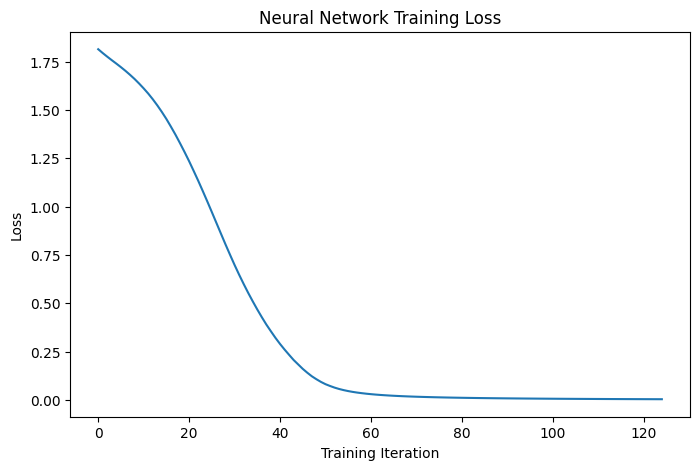

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_curve_)

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")

plt.show()

In [32]:
validation_predictions = model.predict(
    X_validation
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

test_predictions = model.predict(
    X_test
)

test_probabilities = model.predict_proba(
    X_test
)

confidence = test_probabilities.max(axis=1)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(
    f"Validation accuracy: {validation_accuracy:.2%}"
)

print(
    f"Test accuracy: {test_accuracy:.2%}"
)

Validation accuracy: 100.00%
Test accuracy: 100.00%


In [33]:
print(
    classification_report(
        y_test,
        test_predictions
    )
)

                precision    recall  f1-score   support

      CONTRACT       1.00      1.00      1.00        20
EXPENSE_REPORT       1.00      1.00      1.00        20
       INVOICE       1.00      1.00      1.00        20
PURCHASE_ORDER       1.00      1.00      1.00        20
        RESUME       1.00      1.00      1.00        20
SUPPORT_TICKET       1.00      1.00      1.00        20

      accuracy                           1.00       120
     macro avg       1.00      1.00      1.00       120
  weighted avg       1.00      1.00      1.00       120



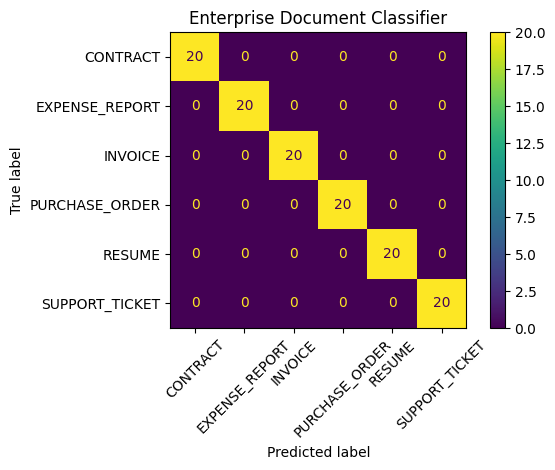

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    xticks_rotation=45
)

plt.title(
    "Enterprise Document Classifier"
)

plt.tight_layout()
plt.show()

In [35]:
correct = test_predictions == y_test

print(
    "Average confidence:",
    f"{confidence.mean():.2%}"
)

print(
    "Correct prediction confidence:",
    f"{confidence[correct].mean():.2%}"
)

if (~correct).any():
    print(
        "Incorrect prediction confidence:",
        f"{confidence[~correct].mean():.2%}"
    )

Average confidence: 99.42%
Correct prediction confidence: 99.42%


In [36]:
operations = pd.DataFrame({
    "document_quality": rng.uniform(
        0.50,
        1.00,
        len(test_data)
    ),

    "business_risk": rng.choice(
        ["LOW", "MEDIUM", "HIGH"],
        len(test_data),
        p=[0.50, 0.35, 0.15]
    ),

    "previous_failures": rng.choice(
        [0, 1, 2, 3],
        len(test_data),
        p=[0.70, 0.20, 0.07, 0.03]
    ),

    "contains_sensitive_data": rng.choice(
        [False, True],
        len(test_data),
        p=[0.80, 0.20]
    )
})

inference_data = (
    test_data
    .reset_index(drop=True)
    .copy()
)

inference_data["prediction"] = (
    test_predictions
)

inference_data["model_confidence"] = (
    confidence
)

inference_data = pd.concat(
    [inference_data, operations],
    axis=1
)

inference_data.head()

,text,document_type,prediction,model_confidence,document_quality,business_risk,previous_failures,contains_sensitive_data
0,Invoice 1009 contains charges for products and...,INVOICE,INVOICE,0.984747,0.734208,HIGH,0,False
1,Order 1094 authorizes Acme Services to supply ...,PURCHASE_ORDER,PURCHASE_ORDER,0.996417,0.629720,MEDIUM,1,False
2,Work experience includes software development ...,RESUME,RESUME,0.994743,0.522587,HIGH,1,False
3,Support request 1090: account login is not wor...,SUPPORT_TICKET,SUPPORT_TICKET,0.995703,0.740746,MEDIUM,1,True
4,"Agreement 1021 establishes obligations, paymen...",CONTRACT,CONTRACT,0.995841,0.979666,MEDIUM,0,False


In [37]:
def hard_policy(row):

    if row["document_quality"] < 0.55:
        return "HUMAN_REVIEW"

    if row["previous_failures"] >= 3:
        return "ESCALATE"

    if (
        row["business_risk"] == "HIGH"
        and row["contains_sensitive_data"]
    ):
        return "HUMAN_REVIEW"

    if row["model_confidence"] < 0.60:
        return "HUMAN_REVIEW"

    return None

In [38]:
def offline_decision(row):

    hard = hard_policy(row)

    if hard:
        return hard

    if (
        row["business_risk"] == "HIGH"
        or row["previous_failures"] >= 2
    ):
        return "HUMAN_REVIEW"

    if (
        row["model_confidence"] >= 0.90
        and row["document_quality"] >= 0.75
    ):
        return "AUTO_PROCESS"

    return "HUMAN_REVIEW"

In [39]:
inference_data["decision"] = (
    inference_data.apply(
        offline_decision,
        axis=1
    )
)

print(
    inference_data[
        "decision"
    ].value_counts()
)

decision
HUMAN_REVIEW    72
AUTO_PROCESS    45
ESCALATE         3
Name: count, dtype: int64


In [40]:
auto_mask = (
    inference_data["decision"]
    == "AUTO_PROCESS"
)

review_mask = (
    inference_data["decision"]
    == "HUMAN_REVIEW"
)

escalation_mask = (
    inference_data["decision"]
    == "ESCALATE"
)

auto_rate = auto_mask.mean()
review_rate = review_mask.mean()
escalation_rate = escalation_mask.mean()

print(
    f"Auto-process: {auto_rate:.2%}"
)

print(
    f"Human review: {review_rate:.2%}"
)

print(
    f"Escalated: {escalation_rate:.2%}"
)

Auto-process: 37.50%
Human review: 60.00%
Escalated: 2.50%


In [41]:
if auto_mask.any():

    auto_accuracy = (
        inference_data.loc[
            auto_mask,
            "prediction"
        ]
        ==
        inference_data.loc[
            auto_mask,
            "document_type"
        ]
    ).mean()

    print(
        "Auto-processed accuracy:",
        f"{auto_accuracy:.2%}"
    )

else:
    auto_accuracy = None

    print(
        "No documents were auto-processed."
    )

Auto-processed accuracy: 100.00%


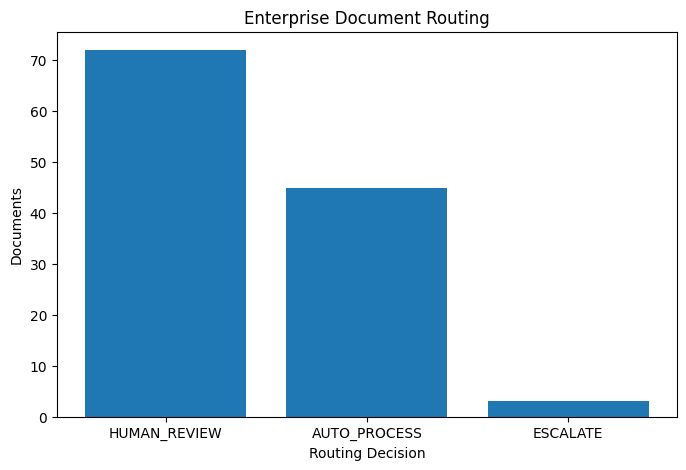

In [42]:
decision_counts = (
    inference_data["decision"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    decision_counts.index,
    decision_counts.values
)

plt.xlabel("Routing Decision")
plt.ylabel("Documents")
plt.title("Enterprise Document Routing")

plt.show()

In [43]:
def ask_jev(row):

    api_key = os.getenv(
        "TYPESAFE_API_KEY"
    )

    if not api_key:
        raise RuntimeError(
            "TYPESAFE_API_KEY is not set."
        )

    payload = {
        "model": JEV_MODEL,

        "state": {
            "predicted_document_type":
                str(row["prediction"]),

            "model_confidence":
                float(row["model_confidence"]),

            "document_quality":
                float(row["document_quality"]),

            "business_risk":
                str(row["business_risk"]),

            "previous_failures":
                int(row["previous_failures"]),

            "contains_sensitive_data":
                bool(row["contains_sensitive_data"])
        },

        "questions": {
            "routing": {
                "type": "choice",

                "instructions": (
                    "Choose the safest processing route "
                    "for this enterprise document using "
                    "the ML confidence, document quality, "
                    "business risk, previous failures, "
                    "and sensitive-data signal."
                ),

                "criteria": {
                    "AUTO_PROCESS": (
                        "Safe for automated processing."
                    ),

                    "HUMAN_REVIEW": (
                        "Requires manual verification."
                    ),

                    "ESCALATE": (
                        "Requires special handling due "
                        "to elevated operational risk."
                    )
                }
            }
        }
    }

    response = requests.post(
        JEV_ENDPOINT,

        headers={
            "Authorization":
                f"Bearer {api_key}",

            "Content-Type":
                "application/json"
        },

        json=payload,
        timeout=10
    )

    response.raise_for_status()

    return response.json()

In [44]:
def route_document(
    row,
    use_jev=False
):

    hard = hard_policy(row)

    if hard:
        return {
            "decision": hard,
            "source": "hard_policy"
        }

    if not use_jev:
        return {
            "decision":
                offline_decision(row),

            "source":
                "offline_policy"
        }

    try:
        response = ask_jev(row)

        return {
            "decision": "JEV_RESPONSE",
            "source": "jev",
            "response": response
        }

    except (
        requests.RequestException,
        RuntimeError
    ):
        return {
            "decision": "HUMAN_REVIEW",
            "source": "jev_fallback"
        }

In [45]:
eligible_mask = inference_data.apply(
    hard_policy,
    axis=1
).isna()

eligible = inference_data[
    eligible_mask
]

print(
    "Jev-eligible documents:",
    len(eligible)
)

Jev-eligible documents: 105


In [46]:
MODEL_PATH = (
    ARTIFACT_DIR
    / "document_classifier.joblib"
)

joblib.dump(
    {
        "vectorizer": vectorizer,
        "model": model
    },
    MODEL_PATH
)

print("Saved:", MODEL_PATH)

Saved: enterprise_document_artifacts/document_classifier.joblib


In [47]:
LOG_PATH = (
    ARTIFACT_DIR
    / "decision_logs.csv"
)

inference_data.to_csv(
    LOG_PATH,
    index=False
)

print("Saved:", LOG_PATH)

Saved: enterprise_document_artifacts/decision_logs.csv


In [48]:
metadata = {
    "created_at":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model_version":
        MODEL_VERSION,

    "model_type":
        "MLPClassifier",

    "architecture":
        [64, 32],

    "features":
        "TF-IDF",

    "classes":
        sorted(
            data[
                "document_type"
            ].unique().tolist()
        ),

    "train_documents":
        len(train_data),

    "validation_documents":
        len(validation_data),

    "test_documents":
        len(test_data),

    "validation_accuracy":
        float(validation_accuracy),

    "test_accuracy":
        float(test_accuracy),

    "average_confidence":
        float(confidence.mean()),

    "auto_process_rate":
        float(auto_rate),

    "human_review_rate":
        float(review_rate),

    "escalation_rate":
        float(escalation_rate),

    "auto_processed_accuracy": (
        float(auto_accuracy)
        if auto_accuracy is not None
        else None
    ),

    "jev_model":
        JEV_MODEL
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print("Saved:", METADATA_PATH)

Saved: enterprise_document_artifacts/metadata.json


In [49]:
def predict_document(text):

    features = vectorizer.transform(
        [text]
    ).toarray()

    probabilities = model.predict_proba(
        features
    )[0]

    index = probabilities.argmax()

    return {
        "prediction":
            str(model.classes_[index]),

        "confidence":
            float(probabilities[index])
    }

In [50]:
def smoke_test():

    # Dataset
    assert len(data) == 600
    assert data["document_type"].nunique() == 6

    # Splits
    assert len(train_data) == 360
    assert len(validation_data) == 120
    assert len(test_data) == 120

    # Model
    assert 0 <= validation_accuracy <= 1
    assert 0 <= test_accuracy <= 1

    assert np.all(
        (confidence >= 0)
        &
        (confidence <= 1)
    )

    # Decisions
    valid_decisions = {
        "AUTO_PROCESS",
        "HUMAN_REVIEW",
        "ESCALATE"
    }

    assert set(
        inference_data[
            "decision"
        ].unique()
    ).issubset(
        valid_decisions
    )

    # Hard-policy check
    risky_document = {
        "document_quality": 0.20,
        "previous_failures": 0,
        "business_risk": "LOW",
        "contains_sensitive_data": False,
        "model_confidence": 0.99
    }

    assert (
        hard_policy(
            risky_document
        )
        ==
        "HUMAN_REVIEW"
    )

    # Artifact check
    assert MODEL_PATH.exists()
    assert METADATA_PATH.exists()
    assert LOG_PATH.exists()

    # Reload model
    loaded = joblib.load(
        MODEL_PATH
    )

    loaded_features = (
        loaded["vectorizer"]
        .transform(
            test_data["text"]
        )
        .toarray()
    )

    loaded_predictions = (
        loaded["model"]
        .predict(
            loaded_features
        )
    )

    assert np.array_equal(
        test_predictions,
        loaded_predictions
    )

    # Inference check
    result = predict_document(
        "Invoice 9000 requests payment "
        "of $500 for services."
    )

    assert result["prediction"] in (
        model.classes_
    )

    assert (
        0
        <= result["confidence"]
        <= 1
    )

    print(
        "✅ Enterprise document pipeline passed."
    )


smoke_test()

✅ Enterprise document pipeline passed.
